<a href="https://colab.research.google.com/github/krishnakumari200424/krishnakumari200424/blob/main/ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from keras.models import Model

In [ ]:
from keras.datasets import cifar10
import numpy as np

# Load CIFAR-10 dataset directly
(X_train, _), (_, _) = cifar10.load_data()
img_arr = X_train[:150].astype('float32') / 255.0  # Normalize and take 150 images
print("Original image shape:", img_arr.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Original image shape: (150, 32, 32, 3)


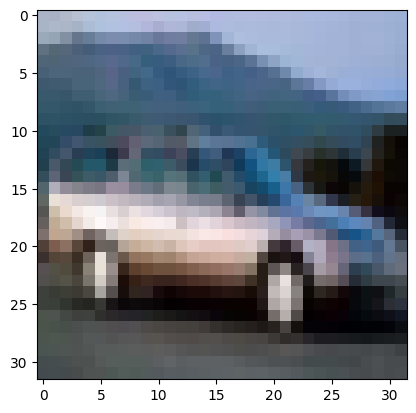

In [ ]:
# Original image
plt.imshow(img_arr[4])
plt.show()

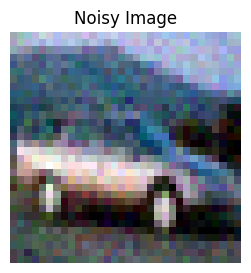

In [ ]:
# Step 3: Add Gaussian noise to the original images
noise_factor = 0.05
noisy_imgs = img_arr + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=img_arr.shape)
noisy_imgs = np.clip(noisy_imgs, 0., 1.)  # Ensuring values are in [0, 1] range

# Visualize one noisy image
plt.figure(figsize=(5, 3))
plt.title("Noisy Image")
plt.imshow(noisy_imgs[4])
plt.axis('off')
plt.show()

In [ ]:
def auto_encoder(img_input):
    f_size = 3
    p_size = 2

    # Encoder
    x = Conv2D(32, (f_size, f_size), activation='relu', padding='same')(img_input)
    x = MaxPooling2D((p_size, p_size), padding='same')(x)
    x = Conv2D(64, (f_size, f_size), activation='relu', padding='same')(x)
    x = MaxPooling2D((p_size, p_size), padding='same')(x)
    x = Conv2D(128, (f_size, f_size), activation='relu', padding='same')(x)

    # Decoder
    x = Conv2D(128, (f_size, f_size), activation='relu', padding='same')(x)
    x = UpSampling2D((p_size, p_size))(x)
    x = Conv2D(64, (f_size, f_size), activation='relu', padding='same')(x)
    x = UpSampling2D((p_size, p_size))(x)
    decoded = Conv2D(3, (f_size, f_size), activation='sigmoid', padding='same')(x)

    return decoded

In [ ]:
img_input = Input(shape=(32, 32, 3))
model = Model(img_input, auto_encoder(img_input))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,355 (1.21 MB)

 Trainable params: 316,355 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(noisy_imgs[:120], img_arr[:120], epochs=10, batch_size=16, validation_split=0.2)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 0.0563 - val_loss: 0.0587
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0483 - val_loss: 0.0681
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0457 - val_loss: 0.0474
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0326 - val_loss: 0.0318
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0268 - val_loss: 0.0289
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0253 - val_loss: 0.0257
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0222 - val_loss: 0.0262
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0233 - val_loss: 0.0206
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0193 - val_loss: 0.0189
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0164 - val_loss: 0.0165


In [ ]:
predicted = model.predict(noisy_imgs)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


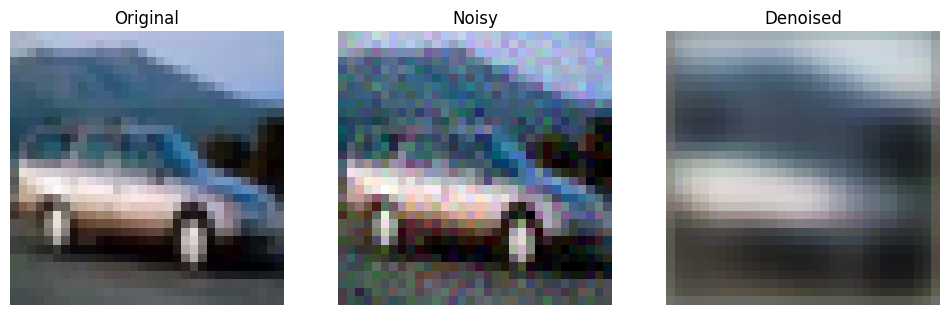

In [ ]:
# Step 8: Visualize results (Training sample)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_arr[4])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(noisy_imgs[4])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Denoised")
plt.imshow(predicted[4])
plt.axis('off')
plt.show()

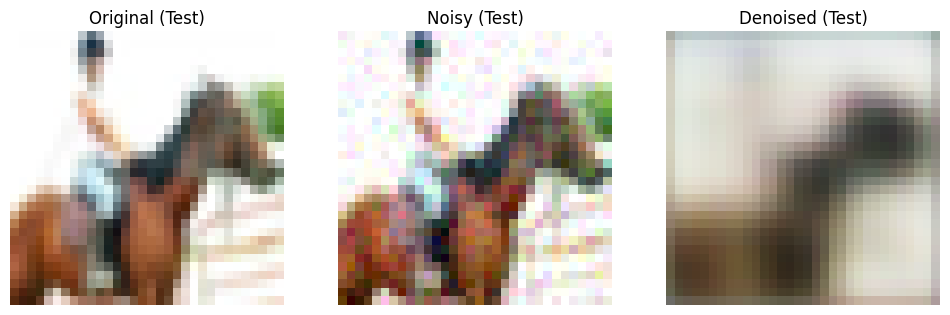

In [ ]:
# Step 9: Visualize results (Test sample)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original (Test)")
plt.imshow(img_arr[131])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy (Test)")
plt.imshow(noisy_imgs[131])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Denoised (Test)")
plt.imshow(predicted[131])
plt.axis('off')
plt.show()